# DAG with labelled edges

Demo of labelling edges on a DAG, for example with effect sizes.

This notebook uses the structure of the DAG based on the synthetic stroke data, but the effect sizes shown are completely made up for this example.

## Code setup

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os
import numpy as np

# Add modules to path:
import sys
sys.path.append('../')  # path to dir containing modules
from modules.create_data import create_stroke_data

## Load in true DAG effects

The values are 0 where the row has no effect on the column and 1 where it does.

In [2]:
p =os.path.join('data', 'synthetic_links.csv')
df_effects = pd.read_csv(p, index_col=0)

In [3]:
df_effects

,afib,warfarin,nihss,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,
year,0,0,0,0,1,0
age,1,0,1,0,1,0
ethnicity,0,0,0,0,1,1
male,0,0,0,0,1,0
afib,0,1,0,0,1,0
warfarin,0,0,0,1,0,0
shoe_size,0,0,0,0,0,0
nihss,0,0,0,1,1,0
thrombolysis_time,0,0,0,0,0,1


Fill in missing columns for nodes that have no parents. These nodes are currently in the index but not in the columns. Then make sure that the column features are in the same order as the index features.

In [4]:
parent_nodes = list(set(df_effects.index) - set(df_effects.columns))

df_effects_full = df_effects.copy()
df_effects_full[parent_nodes] = 0
df_effects_full = df_effects_full[df_effects_full.index]

In [5]:
df_effects_full

,year,age,ethnicity,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,,,,,,,
year,0,0,0,0,0,0,0,0,0,0,1,0
age,0,0,0,0,1,0,0,1,0,0,1,0
ethnicity,0,0,0,0,0,0,0,0,0,0,1,1
male,0,0,0,0,0,0,0,0,0,0,1,0
afib,0,0,0,0,0,1,0,0,0,0,1,0
warfarin,0,0,0,0,0,0,0,0,0,1,0,0
shoe_size,0,0,0,0,0,0,0,0,0,0,0,0
nihss,0,0,0,0,0,0,0,0,0,1,1,0
thrombolysis_time,0,0,0,0,0,0,0,0,0,0,0,1


## Generate effect sizes

Create effect size for each edge. Assume that valid edges are 1 and invalid edges are 0 in the edges dataframe.

In [6]:
nodes = df_effects_full.index

In [9]:
effect_sizes = np.round(np.random.rand(*df_effects_full.values.shape) * df_effects_full.values, 4)
df_effect_sizes = pd.DataFrame(effect_sizes, columns=nodes, index=nodes)

In [10]:
df_effect_sizes

row_causes_column,year,age,ethnicity,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,,,,,,,
year,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,0.0000,0.0,0.0000,0.0025,0.0000
age,0.0,0.0,0.0,0.0,0.607,0.0000,0.0,0.9241,0.0,0.0000,0.0730,0.0000
ethnicity,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,0.0000,0.0,0.0000,0.6456,0.0552
male,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,0.0000,0.0,0.0000,0.8333,0.0000
afib,0.0,0.0,0.0,0.0,0.000,0.8731,0.0,0.0000,0.0,0.0000,0.4192,0.0000
warfarin,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,0.0000,0.0,0.1520,0.0000,0.0000
shoe_size,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000
nihss,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,0.0000,0.0,0.0407,0.9105,0.0000
thrombolysis_time,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.9432


## Convert dataframe into graph

In [11]:
G = nx.from_pandas_adjacency(df_effects_full, create_using=nx.DiGraph)
edges = list(G.edges())

## Setup for plots

Place nodes at these positions:

In [12]:
# Node positions:
pos = {
    'year': (4, 0),
    'age': (3, 0),
    'ethnicity': (6, 0),
    'male': (5, 0),
    'afib': (1, -1),
    'warfarin': (1, -2),
    'shoe_size': (7, 0),
    'nihss': (3, -1),
    'thrombolysis_time': (7, -3),
    'thrombolysis': (2, -3),
    'mortality_prob_no_treatment': (4, -2),
    'mortality_probability': (6, -4),
}

# Pick out coordinates of most extreme nodes:
node_x_min = min([p[0] for p in pos.values()])
node_x_max = max([p[0] for p in pos.values()])
node_y_min = min([p[1] for p in pos.values()])
node_y_max = max([p[1] for p in pos.values()])

Make a dictionary for the edge labels. Each key is an edge (start, end) and each value is its label.

In [13]:
# Define label for each edge:
labels = []
for start_node, end_node in edges:
    # Pick out the value to annotate:
    edge_effect = df_effect_sizes.loc[start_node, end_node]
    label = f'{edge_effect:.2f}'  # show only 2 decimal places
    labels.append(label)
labels = dict(zip(edges, labels)) 

## Plot with labels

To make the labels show up, instead of the basic draw_networkx() function we must use multiple functions to draw each part of the graph in turn.

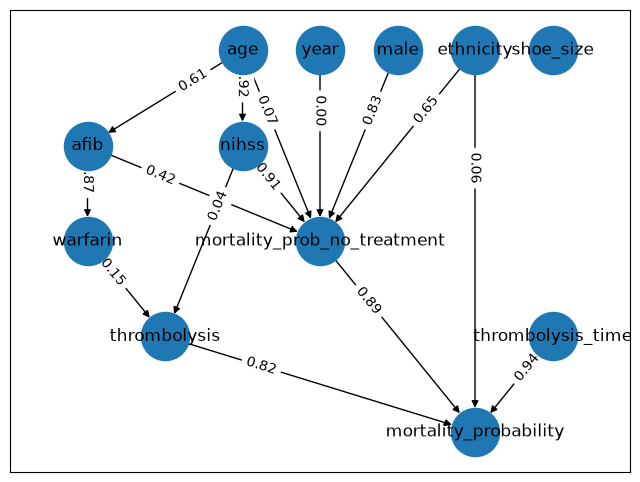

In [14]:
# Need to give node size to both nodes and edges functions:
node_size = 1200

# Draw DAG with networkx:
fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos, node_size=node_size, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)  # node labels

nx.draw_networkx_edges(G, pos, node_size=node_size, ax=ax)

# To not interrupt the lines, use bbox=dict(alpha=0).
# To draw box around each edge label, use bbox=dict(fc='white', ec='black')
nx.draw_networkx_edge_labels(
    G,
    pos,
    labels,
    label_pos=0.3,  # how far along the line to draw the label
    ax=ax,
)

# Modify axis limits for breathing room around labels:
ax.set_xlim(node_x_min-1, node_x_max+1)
# ax.set_ylim(node_y_min-1, node_y_max+1)

plt.show()

Note some limitations of this plot:
+ some edge labels have been partially hidden behind the nodes because the edge arrows are too short to accommodate them.
+ the edge labels could be difficult to read when multiple arrows are located close together.

Some of this could be mitigated by setting particular arrows to curve.

## Plot with curved edges and labels

Set up a function to decide how much each line should curve.

For each edge, make a different curve depending on whether the end point is further left or right from the start point.

In [15]:
def make_connectionstyle_dict(edges, pos, rad=0.15):
    """
    Build a dictionary of arrow curves depending on x position.

    connectionstyle string works with arc3 and angle3.

    Inputs
    ------
    edges - list. List of tuples (start node, end node) for edges.
    pos   - dict. (x,y) coordinates for each node.
    rad   - float. Bendiness of the arrow.

    Returns
    -------
    d - dict. Each edge is a key, each value is a string defining
        the arrow connection style e.g. "arc3,rad=0.15".
    """
    # Calculate a separate rad for each curve:
    rads = []
    for start_node, end_node in edges:
        # X coordinates of nodes:
        x_start = pos[start_node][0]
        x_end = pos[end_node][0]
        # Choose curve depending on whether start x is left or
        # right of end x:
        if x_start < x_end:
            r = rad
        elif x_start == x_end:
            r = 0.0
        else:
            r = -rad
        rads.append(r)
    # Turn these values into a dictionary so they can be matched to
    # each edge:
    d = dict(zip(edges, [f"arc3,rad={r}" for r in rads]))
    return d

Run the function for our edges and node positions:

In [16]:
dict_connectionstyle = make_connectionstyle_dict(edges, pos)

Check the connection styles for the first few edges:

In [17]:
for k in list(dict_connectionstyle.keys())[:3]:
    print(k, dict_connectionstyle[k])

('year', 'mortality_prob_no_treatment') arc3,rad=0.0
('age', 'afib') arc3,rad=-0.15
('age', 'nihss') arc3,rad=0.0


Plot the DAG with curved lines. This time each edge and label needs to be drawn separately rather than in a single call to the draw_networkx_edges() functions.

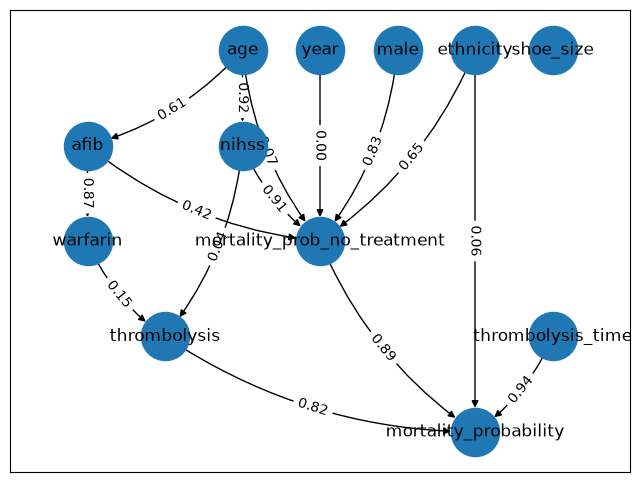

In [18]:
# Need to give node size to both nodes and edges functions:
node_size = 1200

# Draw DAG with networkx:
fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos, node_size=node_size, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)  # node labels

# Draw each edge and its label separately so that a different
# curve (connectionstyle) can be given each time:
for edge in edges:
    # Set up params for this edge only:
    c = dict_connectionstyle[edge]
    edges_here = [edge]
    labels_here = {edge: labels[edge]}
    # Draw the specific edge/arrow
    nx.draw_networkx_edges(
        G, pos, edgelist=edges_here, connectionstyle=c, node_size=node_size,
    )
    # Draw the specific edge label matching the connectionstyle
    nx.draw_networkx_edge_labels(G, pos, labels_here, connectionstyle=c)

# Modify axis limits for breathing room around labels:
ax.set_xlim(node_x_min-1, node_x_max+1)
# ax.set_ylim(node_y_min-1, node_y_max+1)

plt.show()

In this case, the curved graph seems more cluttered than the straight edge version. Used more carefully however there is potential to better space apart edges that would ordinarily be too close together. For example, if two nodes were connected with an arrow in each direction, the arrows could be made to curve differently so that they don't sit directly on top of each other.